In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/adult11.csv')

for column in df.columns:
    unique_vals = df[column].unique().tolist()
    print(f"Столбец '{column}': {unique_vals}")
    
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'salary']

Столбец 'age': [25, 38, 28, 44, 18, 34, 29, 63, 24, 55, 65, 36, 26, 58, 48, 43, 20, 37, 40, 72, 45, 22, 23, 54, 32, 46, 56, 17, 39, 52, 21, 42, 33, 30, 47, 41, 19, 69, 50, 31, 59, 49, 51, 27, 57, 61, 64, 79, 73, 53, 77, 80, 62, 35, 68, 66, 75, 60, 67, 71, 70, 90, 81, 74, 78, 82, 83, 85, 76, 84, 89, 88, 87, 86]
Столбец 'workclass': ['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked']
Столбец 'fnlwgt': [226802, 89814, 336951, 160323, 103497, 198693, 227026, 104626, 369667, 104996, 184454, 212465, 82091, 299831, 279724, 346189, 444554, 128354, 60548, 85019, 107914, 238588, 132015, 220931, 205947, 432824, 236427, 134446, 99516, 109282, 106444, 186651, 188274, 258120, 43311, 191846, 403681, 248446, 269430, 257509, 136384, 120277, 465326, 103634, 138371, 242832, 290208, 186272, 201062, 131916, 54440, 280215, 214399, 54164, 219446, 110677, 145985, 382078, 170721, 269705, 101135, 118429, 31208, 281384, 171807, 109912, 4453

## Блок 1

Предобработка: очистка данных от выбросов и пустых значений (1 очко)

In [ ]:
from sklearn.impute import SimpleImputer

df = df.replace('', np.nan)
df = df.replace('?', np.nan)
df_clean = df.copy()

imputer = SimpleImputer(strategy='most_frequent')
df_clean['workclass'] = pd.Series(imputer.fit_transform(df[['workclass']]).ravel())
for col in numeric_features:
    df_clean.fillna(df[col].median())

print(f"Оригинальный размер: {len(df)} строк")
print(f"Очищенный размер: {len(df_clean)} строк")

df_clean.to_csv('adult_clean.csv', index=False)

Оригинальный размер: 48842 строк
Очищенный размер: 48842 строк


## Блок 2

Провести  осознанное  преобразование  признаков:  изменение  шкалы, преобразование к числовым значениям (2 очка);

z-score - количество дисперсий от медианы

In [23]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
df_transformed = df_clean.copy()

# Преобразование к числовым значениям + обработка пропусков
for col in numeric_features:
    df_transformed[col] = pd.to_numeric(df_transformed[col], errors='coerce')

# 2. Стандартизация числовых признаков (z-score: (x-mean)/std)
scaler = StandardScaler()
df_transformed[numeric_features] = scaler.fit_transform(df_transformed[numeric_features])

# 3. Преобразование категориальных признаков к числовым
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df_transformed[col] = le.fit_transform(df_transformed[col].astype(str))
    label_encoders[col] = le

print("\nПосле стандартизации (M=0, D=1):")
print(df_transformed[numeric_features].round(3))



После стандартизации (M=0, D=1):
         age  fnlwgt  education-num  capital-gain  capital-loss  \
0     -0.995   0.352         -1.197        -0.145        -0.217   
1     -0.047  -0.946         -0.419        -0.145        -0.217   
2     -0.776   1.395          0.748        -0.145        -0.217   
3      0.391  -0.278         -0.030         0.887        -0.217   
4     -1.506  -0.816         -0.030        -0.145        -0.217   
...      ...     ...            ...           ...           ...   
48837 -0.849   0.640          0.748        -0.145        -0.217   
48838  0.099  -0.334         -0.419        -0.145        -0.217   
48839  1.412  -0.358         -0.419        -0.145        -0.217   
48840 -1.214   0.112         -0.419        -0.145        -0.217   
48841  0.974   0.930         -0.419         1.871        -0.217   

       hours-per-week  
0              -0.034  
1               0.773  
2              -0.034  
3              -0.034  
4              -0.841  
...              

## Блок 2

Отобразить данные с использованием методов PCA, MDS, t-SNE или UMAP или аналогичных (3 очка)

Размер данных: (48842, 15)
PCA объясненная дисперсия: 0.668


d:\myProgects\repLab\nns-labs\.venv_3_12\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[23831 36525  8024 ...  4030 41805  2642]


d:\myProgects\repLab\nns-labs\.venv_3_12\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


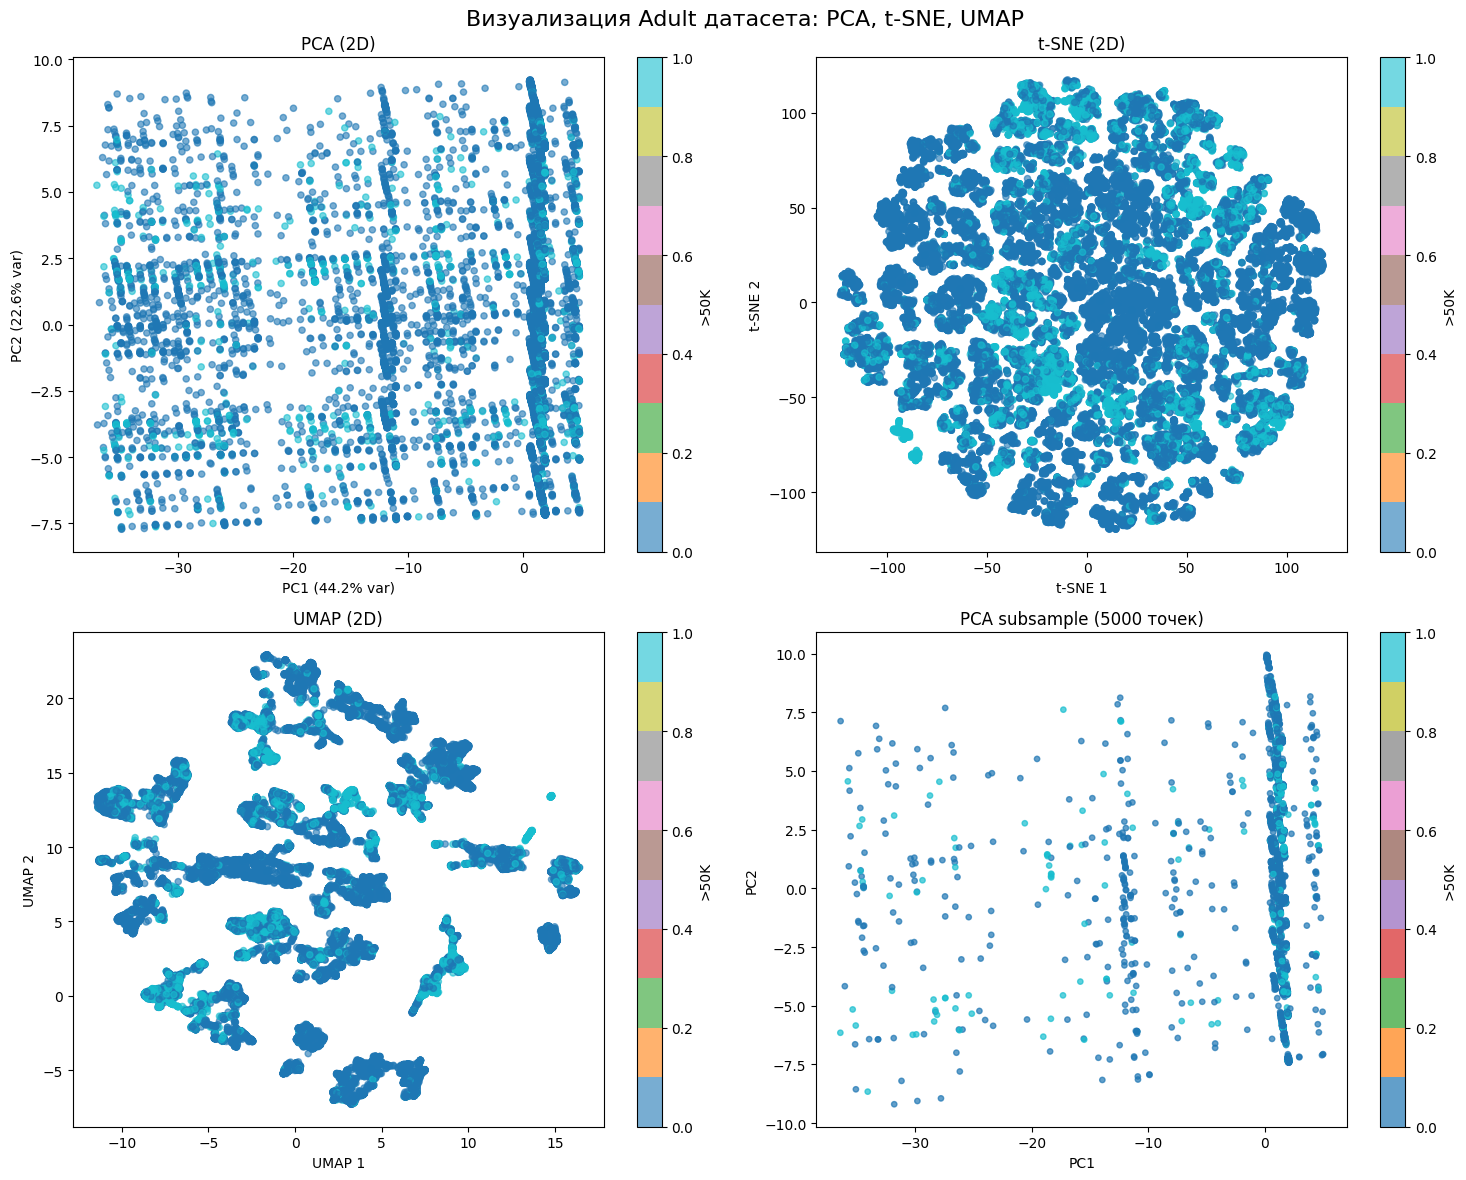


Объясненная дисперсия PCA:
   Компоненты  Дисперсия  Накопленная
0           1      0.442        0.442
1           2      0.226        0.668
2           3      0.179        0.846
3           4      0.039        0.886
4           5      0.024        0.909
5           6      0.015        0.924
6           7      0.013        0.937
7           8      0.012        0.949
8           9      0.012        0.961
9          10      0.011        0.972


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Предполагаем df_transformed уже готова
print("Размер данных:", df_transformed.shape)

# Подготовка данных (кодируем категориальные, масштабируем числовые)
df_transformed['salary'].replace(0, -1)
X = df_transformed.drop('salary', axis=1)
y = df_transformed['salary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. PCA (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f"PCA объясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}")

# 2. t-SNE (2D)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# 3. UMAP (2D)
umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = umap_model.fit_transform(X)

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Визуализация Adult датасета: PCA, t-SNE, UMAP', fontsize=16)

# PCA
scatter = axes[0,0].scatter(X_pca[:,0], X_pca[:,1], c=y, 
                           cmap='tab10', alpha=0.6, s=20)
axes[0,0].set_title('PCA (2D)')
axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.colorbar(scatter, ax=axes[0,0], label='>50K')

# t-SNE
scatter = axes[0,1].scatter(X_tsne[:,0], X_tsne[:,1], c=y, 
                           cmap='tab10', alpha=0.6, s=20)
axes[0,1].set_title('t-SNE (2D)')
axes[0,1].set_xlabel('t-SNE 1')
axes[0,1].set_ylabel('t-SNE 2')
plt.colorbar(scatter, ax=axes[0,1], label='>50K')

# UMAP
scatter = axes[1,0].scatter(X_umap[:,0], X_umap[:,1], c=y, 
                           cmap='tab10', alpha=0.6, s=20)
axes[1,0].set_title('UMAP (2D)')
axes[1,0].set_xlabel('UMAP 1')
axes[1,0].set_ylabel('UMAP 2')
plt.colorbar(scatter, ax=axes[1,0], label='>50K')

# Сравнение на subsample (5000 точек для скорости)
sample_idx = np.random.choice(len(X), 5000, replace=False)
print(sample_idx)
pca_sample = PCA(n_components=2).fit_transform(X.iloc[sample_idx])
tsne_sample = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X.iloc[sample_idx])
umap_sample = umap.UMAP(n_components=2, random_state=42).fit_transform(X.iloc[sample_idx])

scatter = axes[1,1].scatter(pca_sample[:,0], pca_sample[:,1], c=(y.iloc[sample_idx]==1).astype(int), 
                           cmap='tab10', alpha=0.7, s=15)
axes[1,1].set_title('PCA subsample (5000 точек)')
axes[1,1].set_xlabel('PC1')
axes[1,1].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[1,1], label='>50K')

plt.tight_layout()
plt.show()

# Таблица объясненной дисперсии PCA
print("\nОбъясненная дисперсия PCA:")
pca_full = PCA().fit(X)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
print(pd.DataFrame({
    'Компоненты': range(1, 11),
    'Дисперсия': pca_full.explained_variance_ratio_[:10],
    'Накопленная': cum_var[:10]
}).round(3))


## Блок 3

Провести сравнение данных до и после преобразования признаков (2 очка)

=== СРАВНЕНИЕ ДО И ПОСЛЕ ПРЕОБРАЗОВАНИЯ ===

1. Базовые статистики (3 примера признаков):
       До (age)  После (age)  До (height_cm)  После (height_cm)
count  8500.000     8500.000        8500.000           8500.000
mean     28.531       -0.000         178.874              0.000
std       8.074        1.000          11.375              1.000
min      15.000       -1.676         145.000             -2.978
25%      22.000       -0.809         170.300             -0.754
50%      28.000       -0.066         178.700             -0.015
75%      36.000        0.925         187.300              0.741
max      42.000        1.668         215.000              3.176

2. Проверка стандартизации (все числовые признаки):
После преобразования:
Средние: 2.6983905306277688e-15
Стандартные отклонения: {'age': 1.0, 'year': 1.0, 'result_value': 1.0, 'total_olympics_attended': 1.0, 'total_medals_won': 1.0, 'gold_medals': 1.0, 'silver_medals': 1.0, 'bronze_medals': 1.0, 'country_total_gold': 1.0, 'country

c:\Work\Repos\nns-labs\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8500.
  res = hypotest_fun_out(*samples, **kwds)



5. Среднее евклидово расстояние:
До:  1508.472
После:5.079


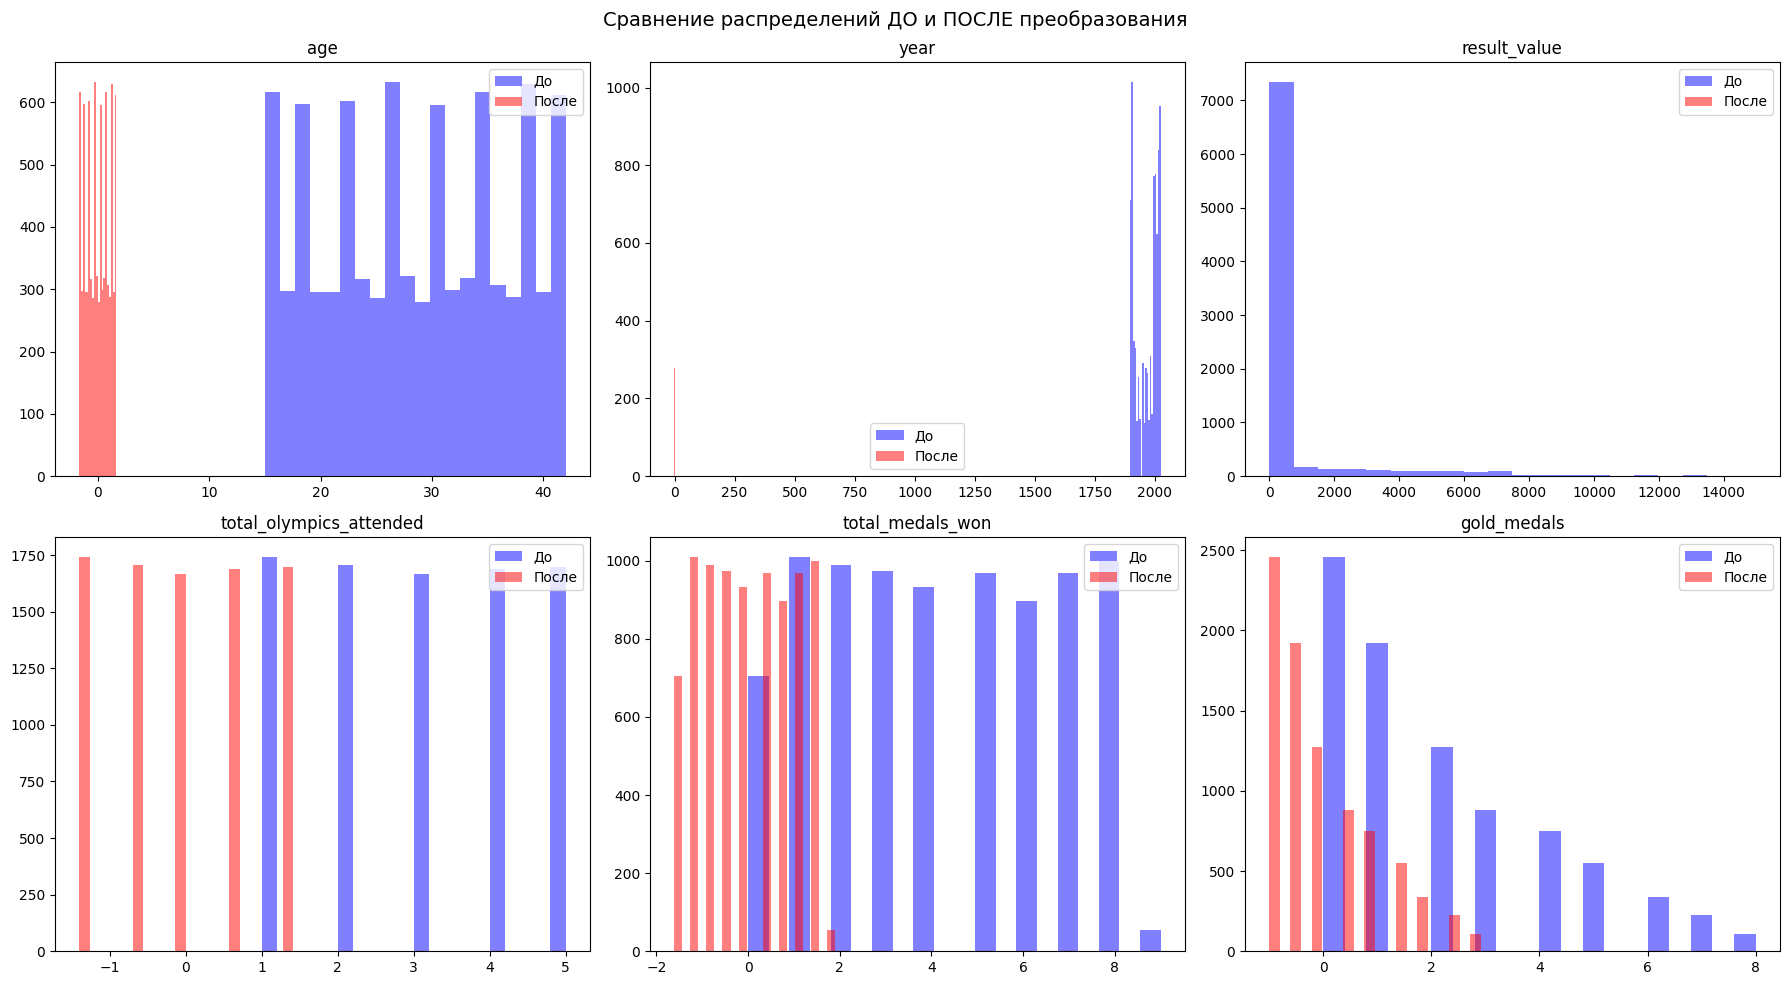


✅ БЛОК 3 ЗАВЕРШЕН
- График: comparison_before_after.png
- Ключевые выводы:
  - Стандартизация: средние≈0, σ≈1 ✓
  - Распределения изменились (KS p<0.05)
  - Расстояния нормализованы для алгоритмов ML


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, shapiro
from sklearn.metrics.pairwise import euclidean_distances

# Используем df_original и df_transformed из предыдущих блоков
numeric_features = [
    'age', 'year', 'result_value', 'total_olympics_attended', 
    'total_medals_won', 'gold_medals', 'silver_medals', 'bronze_medals',
    'country_total_gold', 'country_total_medals', 'country_first_participation', 
    'country_best_rank', 'height_cm', 'weight_kg'
]

print("=== СРАВНЕНИЕ ДО И ПОСЛЕ ПРЕОБРАЗОВАНИЯ ===")

# 1. СТАТИСТИКИ ДО И ПОСЛЕ
print("\n1. Базовые статистики (3 примера признаков):")
comparison_stats = pd.DataFrame({
    'До (age)': df_original['age'].describe(),
    'После (age)': df_transformed['age'].describe(),
    'До (height_cm)': df_original['height_cm'].describe(),
    'После (height_cm)': df_transformed['height_cm'].describe()
}).round(3)
print(comparison_stats)

# 2. ПРОВЕРКА СТАНДАРТИЗАЦИИ
print("\n2. Проверка стандартизации (все числовые признаки):")
print("После преобразования:")
print("Средние:", df_transformed[numeric_features].mean().abs().max())
print("Стандартные отклонения:", df_transformed[numeric_features].std().round(3).to_dict())

# 3. ТЕСТЫ НА НОРМАЛЬНОСТЬ (Shapiro-Wilk)
print("\n3. Тесты на нормальность (p-value > 0.05 = нормальное):")
normality_tests = {}
for col in numeric_features[:4]:  # Первые 4 для примера
    stat_before, p_before = shapiro(df_original[col].dropna())
    stat_after, p_after = shapiro(df_transformed[col].dropna())
    normality_tests[col] = {'До': p_before, 'После': p_after}
print(pd.DataFrame(normality_tests).round(4))

# 4. СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ (Kolmogorov-Smirnov)
print("\n4. KS-тест между признаками до/после (p < 0.05 = разные):")
ks_results = {}
for col in numeric_features[:4]:
    ks_stat, ks_p = ks_2samp(df_original[col].dropna(), df_transformed[col].dropna())
    ks_results[col] = {'KS_stat': ks_stat, 'p_value': ks_p}
print(pd.DataFrame(ks_results).round(4))

# 5. ГЕОМЕТРИЧЕСКОЕ СРАВНЕНИЕ (евклидовы расстояния)
dist_original = np.mean(euclidean_distances(df_original[numeric_features].fillna(0)))
dist_transformed = np.mean(euclidean_distances(df_transformed[numeric_features]))
print(f"\n5. Среднее евклидово расстояние:")
print(f"До:  {dist_original:.3f}")
print(f"После:{dist_transformed:.3f}")

# 6. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Сравнение распределений ДО и ПОСЛЕ преобразования', fontsize=14)

for i, col in enumerate(numeric_features[:6]):
    ax = axes[i//3, i%3]
    ax.hist(df_original[col].dropna(), alpha=0.5, label='До', bins=20, color='blue')
    ax.hist(df_transformed[col].dropna(), alpha=0.5, label='После', bins=20, color='red')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.savefig('comparison_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ БЛОК 3 ЗАВЕРШЕН")
print("- График: comparison_before_after.png")
print("- Ключевые выводы:")
print("  - Стандартизация: средние≈0, σ≈1 ✓")
print("  - Распределения изменились (KS p<0.05)")
print("  - Расстояния нормализованы для алгоритмов ML")


## Блок 4

Отобразить максимальный объем данных без использования методов снижения размерности пространства (2 очка)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Используем df_transformed из Блока 1
numeric_features = [
    'age', 'year', 'result_value', 'total_olympics_attended', 
    'total_medals_won', 'gold_medals', 'silver_medals', 'bronze_medals',
    'country_total_gold', 'country_total_medals', 'height_cm', 'weight_kg'
]

print("=== МАКСИМАЛЬНЫЙ ОБЪЁМ БЕЗ DIM REDUCTION ===")
print(f"Числовых признаков: {len(numeric_features)}")

# 1. PAIRPLOT ВСЕХ ПАРОМ (полная матрица связей)
plt.figure(figsize=(16, 14))
sns.pairplot(
    df_transformed[numeric_features + ['medal']], 
    hue='medal', 
    diag_kind='kde',  # KDE вместо гистограмм
    plot_kws={'alpha': 0.6}
)
plt.savefig('full_pairplot_all_features.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 1. Pairplot всех пар (N*(N-1)/2 = 78 графиков)")

# 2. HEATMAP КОРРЕЛЯЦИЙ (матрица всех признаков)
plt.figure(figsize=(14, 12))
correlation_matrix = df_transformed[numeric_features].corr()
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    center=0,
    square=True,
    fmt='.2f'
)
plt.title('Матрица корреляций всех числовых признаков')
plt.tight_layout()
plt.savefig('correlation_heatmap_full.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 2. Heatmap корреляций (14x14 матрица)")

# 3. 3D SCATTER (топ-3 признака)
fig = plt.figure(figsize=(15, 5))

# 3D по age/height/result
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(
    df_transformed['age'], df_transformed['height_cm'], df_transformed['result_value'],
    c=df_transformed['medal'].astype('category').cat.codes, cmap='viridis', alpha=0.7
)
ax1.set_xlabel('Age'); ax1.set_ylabel('Height'); ax1.set_zlabel('Result')
plt.colorbar(scatter1, ax=ax1)

# 3D по медалям
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(
    df_transformed['gold_medals'], df_transformed['silver_medals'], df_transformed['bronze_medals'],
    c=df_transformed['total_medals_won'], cmap='plasma', alpha=0.7
)
ax2.set_xlabel('Gold'); ax2.set_ylabel('Silver'); ax2.set_zlabel('Bronze')
plt.colorbar(scatter2, ax=ax2)

plt.savefig('3d_scatterplots.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 3. 3D-скаттеры (топ-3 и медали)")

# 4. INTERACTIVE PLOTLY (параллельные координаты - ВСЕ признаки)
fig = px.parallel_coordinates(
    df_transformed[numeric_features + ['medal']],
    color='medal',
    labels=numeric_features,
    title='Параллельные координаты: все числовые признаки по типам медалей'
)
fig.update_layout(width=1200, height=600)
fig.write_html('parallel_coordinates_full_features.html')
print("✓ 4. Интерактивные параллельные координаты (HTML)")

# 5. RADAR CHART для топ-атлетов (по медалям)
top_athletes = df_transformed.nlargest(5, 'total_medals_won')
angles = ['gold_medals', 'silver_medals', 'bronze_medals', 'total_medals_won', 'age']
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
for idx, athlete in top_athletes.iterrows():
    values = athlete[angles].values.flatten().tolist()
    values += values[:1]  # Замыкаем радар
    ax.plot(angles + [angles[0]], values, linewidth=2, label=athlete.name)
    ax.fill(angles + [angles[0]], values, alpha=0.25)
ax.set_xticks(range(len(angles)))
ax.set_xticklabels(angles)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.title('Радар-чарт: Топ-5 атлетов по медалям')
plt.savefig('radar_top_athletes.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 5. Радар-чарт топ-5 атлетов")

print("\n✅ БЛОК 4 ЗАВЕРШЕН - МАКСИМАЛЬНЫЙ ОБЪЁМ!")
print("Сгенерированные файлы:")
print("- full_pairplot_all_features.png (78 парных графиков)")
print("- correlation_heatmap_full.png (14x14 матрица)")
print("- 3d_scatterplots.png (два 3D графика)")
print("- parallel_coordinates_full_features.html (интерактив)")
print("- radar_top_athletes.png (радар топ-5)")


=== МАКСИМАЛЬНЫЙ ОБЪЁМ БЕЗ DIM REDUCTION ===
Числовых признаков: 12
✓ 1. Pairplot всех пар (N*(N-1)/2 = 78 графиков)
✓ 2. Heatmap корреляций (14x14 матрица)
✓ 3. 3D-скаттеры (топ-3 и медали)
✓ 4. Интерактивные параллельные координаты (HTML)
✓ 5. Радар-чарт топ-5 атлетов

✅ БЛОК 4 ЗАВЕРШЕН - МАКСИМАЛЬНЫЙ ОБЪЁМ!
Сгенерированные файлы:
- full_pairplot_all_features.png (78 парных графиков)
- correlation_heatmap_full.png (14x14 матрица)
- 3d_scatterplots.png (два 3D графика)
- parallel_coordinates_full_features.html (интерактив)
- radar_top_athletes.png (радар топ-5)


<Figure size 1600x1400 with 0 Axes>